## Загрузка и объединение

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_excel('X_bp.xlsx')
df2 = pd.read_excel('X_nup.xlsx')

df = pd.merge(df1, df2, on = 'id', how='inner')
df = df.drop('id', axis=1)

df.head()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.0,738.736842,30.00,22.267857,100.000000,210.0,70.0,3000.0,220.0,0,4.0,57.0
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
2,1.857143,2030.0,738.736842,49.90,33.000000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,70.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0


## Первичный осмотр

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1023 non-null   float64
 1   Плотность, кг/м3                      1023 non-null   float64
 2   модуль упругости, ГПа                 1023 non-null   float64
 3   Количество отвердителя, м.%           1023 non-null   float64
 4   Содержание эпоксидных групп,%_2       1023 non-null   float64
 5   Температура вспышки, С_2              1023 non-null   float64
 6   Поверхностная плотность, г/м2         1023 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1023 non-null   float64
 8   Прочность при растяжении, МПа         1023 non-null   float64
 9   Потребление смолы, г/м2               1023 non-null   float64
 10  Угол нашивки, град                    1023 non-null   int64  
 11  Шаг нашивки                 

In [3]:
df.shape

(1023, 13)

In [4]:
df.describe()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000
mean,2.930366,1975.734888,739.923233,110.570769,22.244390,285.882151,482.731833,73.328571,2466.922843,218.423144,44.252199,6.899222,57.153929
std,0.913222,73.729231,330.231581,28.295911,2.406301,40.943260,281.314690,3.118983,485.628006,59.735931,45.015793,2.563467,12.350969
min,0.389403,1731.764635,2.436909,17.740275,14.254985,100.000000,0.603740,64.054061,1036.856605,33.803026,0.000000,0.000000,0.000000
25%,2.317887,1924.155467,500.047452,92.443497,20.608034,259.066528,266.816645,71.245018,2135.850448,179.627520,0.000000,5.080033,49.799212
50%,2.906878,1977.621657,739.664328,110.564840,22.230744,285.896812,451.864365,73.268805,2459.524526,219.198882,0.000000,6.916144,57.341920
75%,3.552660,2021.374375,961.812526,129.730366,23.961934,313.002106,693.225017,75.356612,2767.193119,257.481724,90.000000,8.586293,64.944961
max,5.591742,2207.773481,1911.536477,198.953207,33.000000,413.273418,1399.542362,82.682051,3848.436732,414.590628,90.000000,14.440522,103.988901


## EDA

### Распределения

In [5]:
name_cols = df.columns.tolist()
name_cols.remove('Угол нашивки, град')
name_cols

['Соотношение матрица-наполнитель',
 'Плотность, кг/м3',
 'модуль упругости, ГПа',
 'Количество отвердителя, м.%',
 'Содержание эпоксидных групп,%_2',
 'Температура вспышки, С_2',
 'Поверхностная плотность, г/м2',
 'Модуль упругости при растяжении, ГПа',
 'Прочность при растяжении, МПа',
 'Потребление смолы, г/м2',
 'Шаг нашивки',
 'Плотность нашивки']

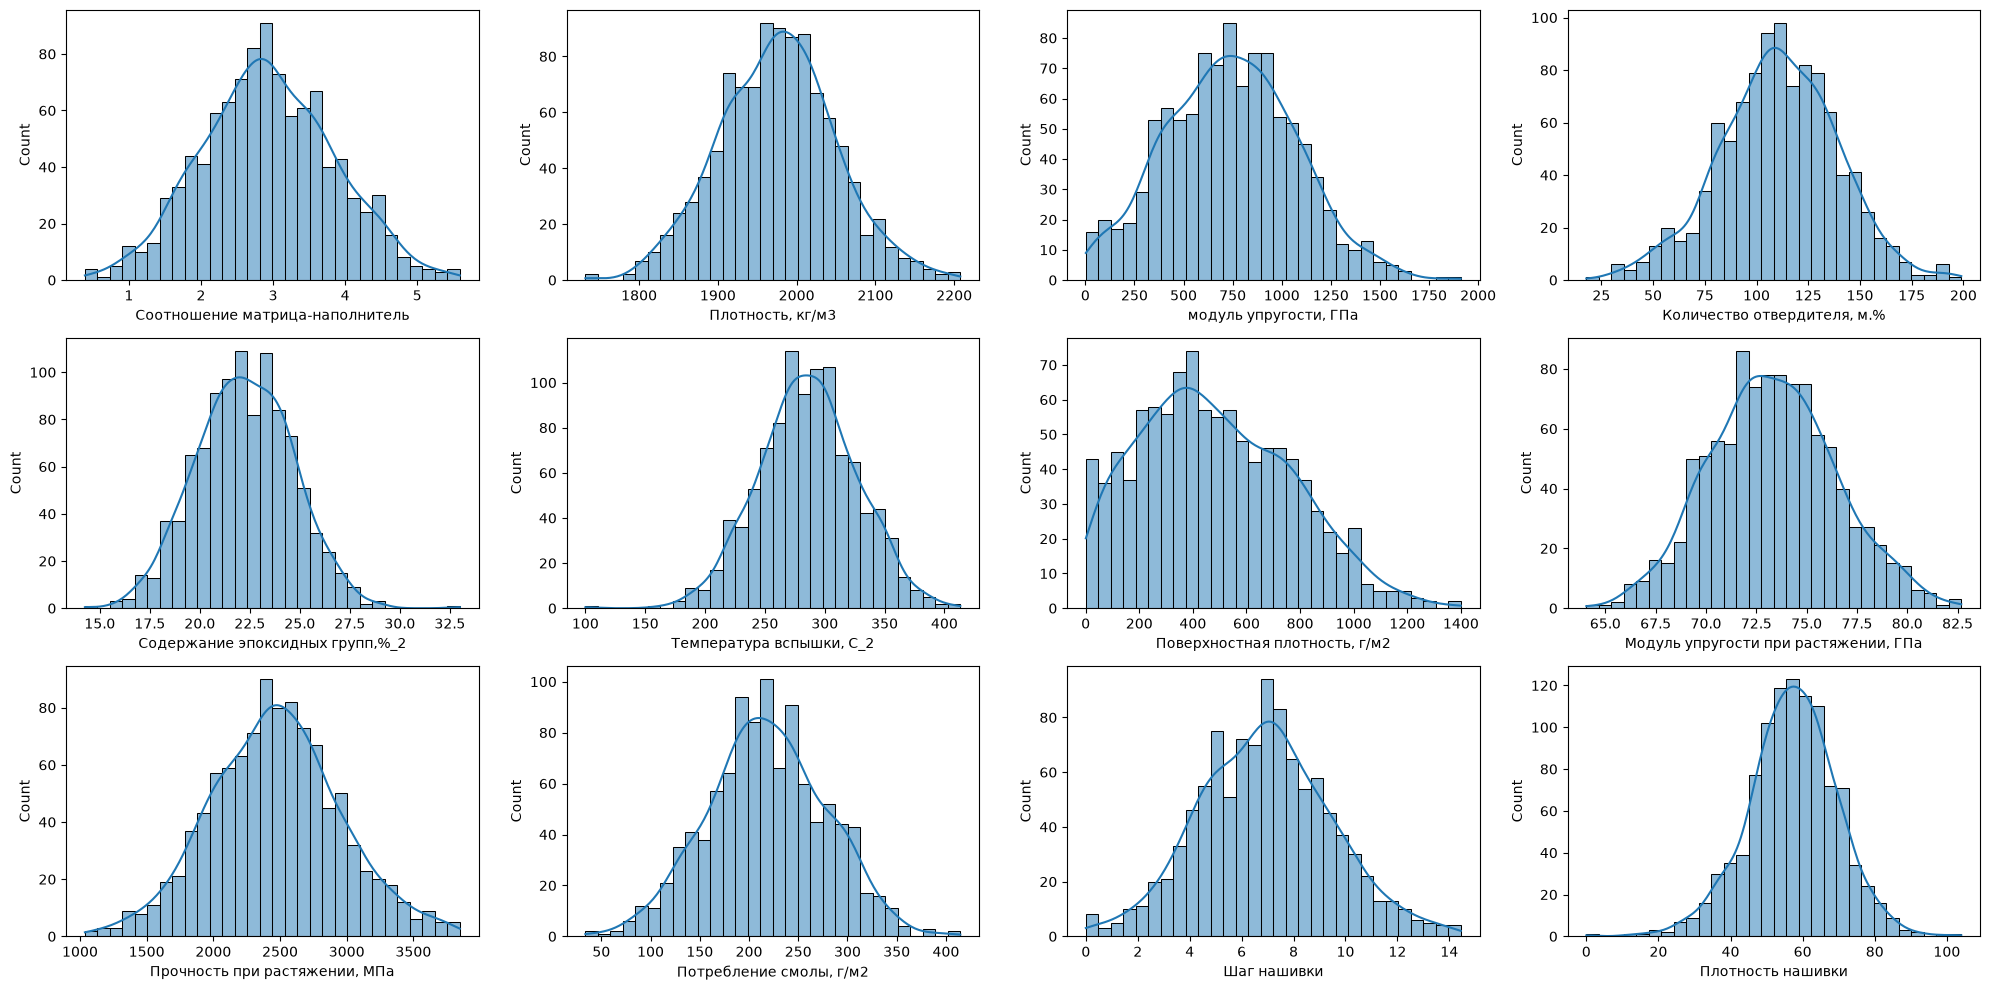

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(20, 10)) 

for ax, col in zip(axes.ravel(), name_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)

plt.tight_layout()
plt.show()

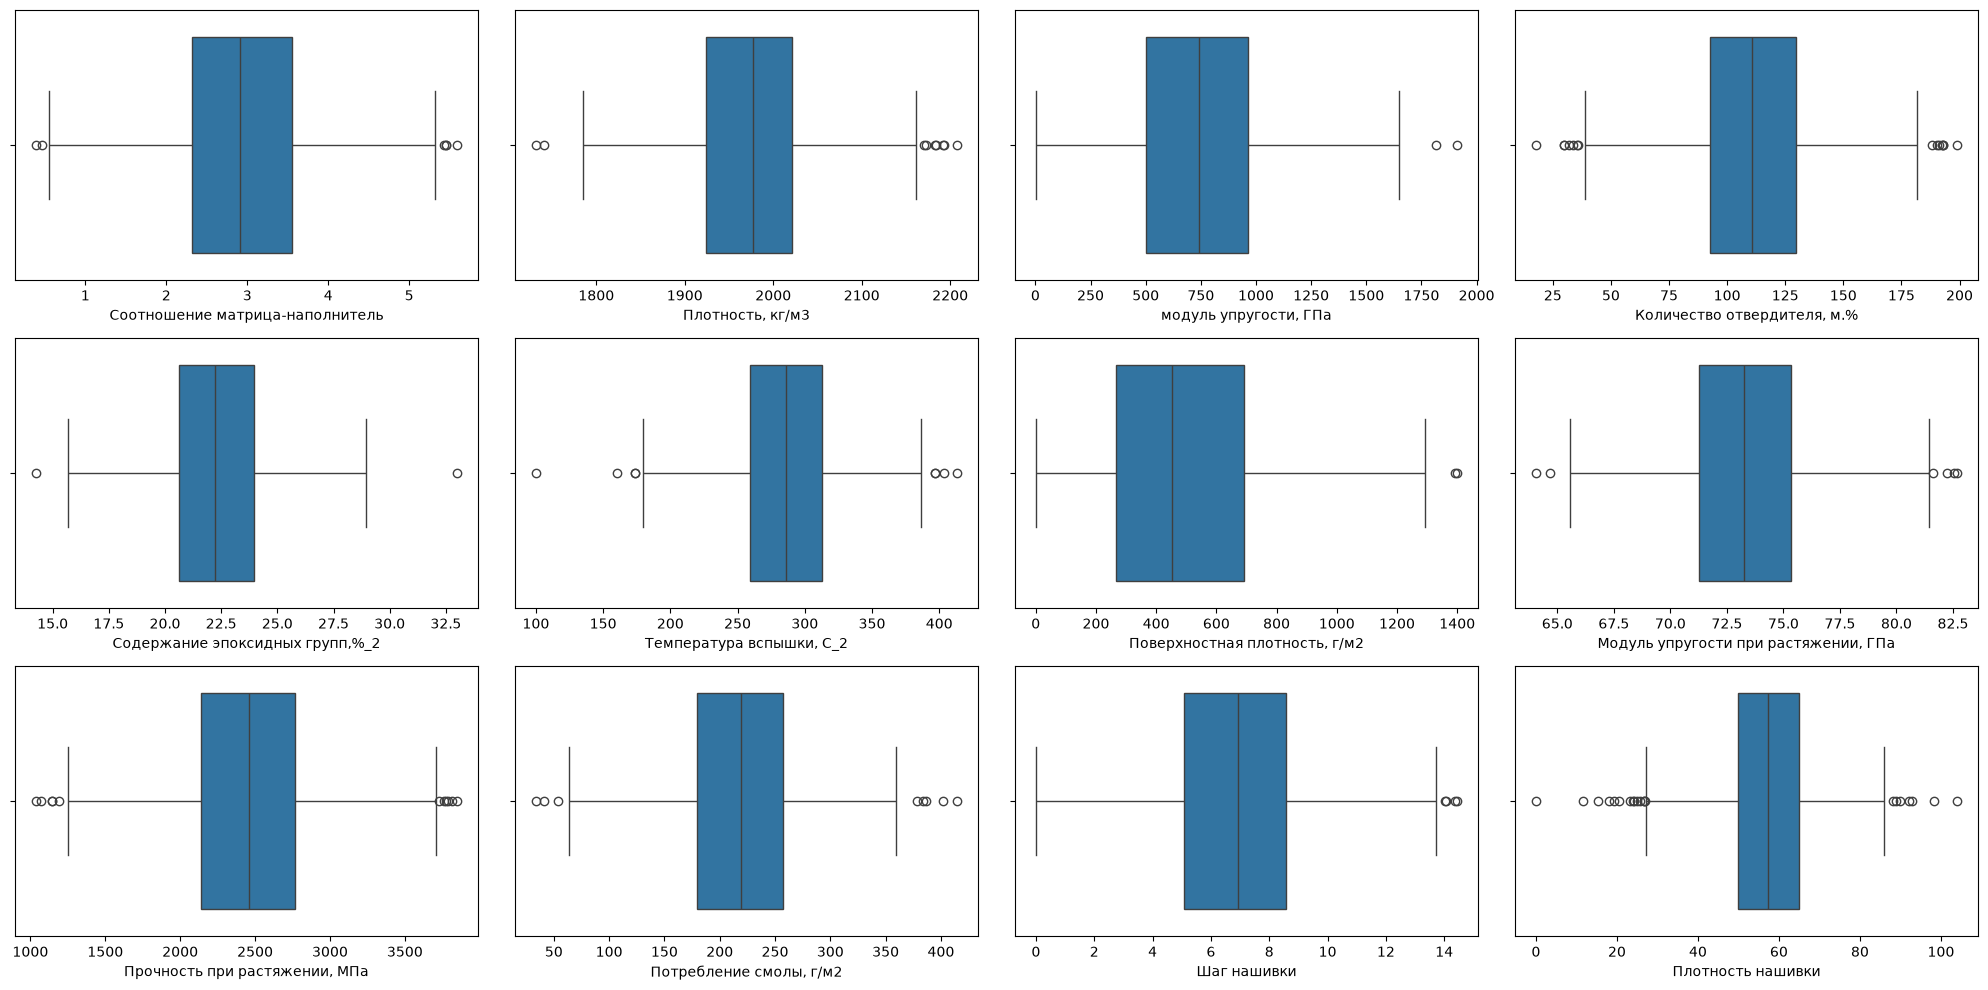

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(20, 10)) 

for ax, col in zip(axes.ravel(), name_cols):
    sns.boxplot(x=df[col], ax=ax)

plt.tight_layout()
plt.show()

Явных выбросов не обнаруженно, но было замечено значение 0 в плотности нашивки, что вроде как не возможно, поэтому с этим пропуском надо поработать отдельно

In [8]:
p_patch = df[df['Плотность нашивки'] == 0]
p_patch

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
19,3.532338,1980.0,1183.0,111.86,22.267857,284.615385,1010.0,78.0,2000.0,300.0,0,0.0,0.0


In [9]:
(len(p_patch) * 100) / len(df)

0.09775171065493646

Дополнительный анализ показал, что данные значения не является пропуском и оно получилось в результате того что шаг нашивки тоже 0

### Корреляция числовых признаков

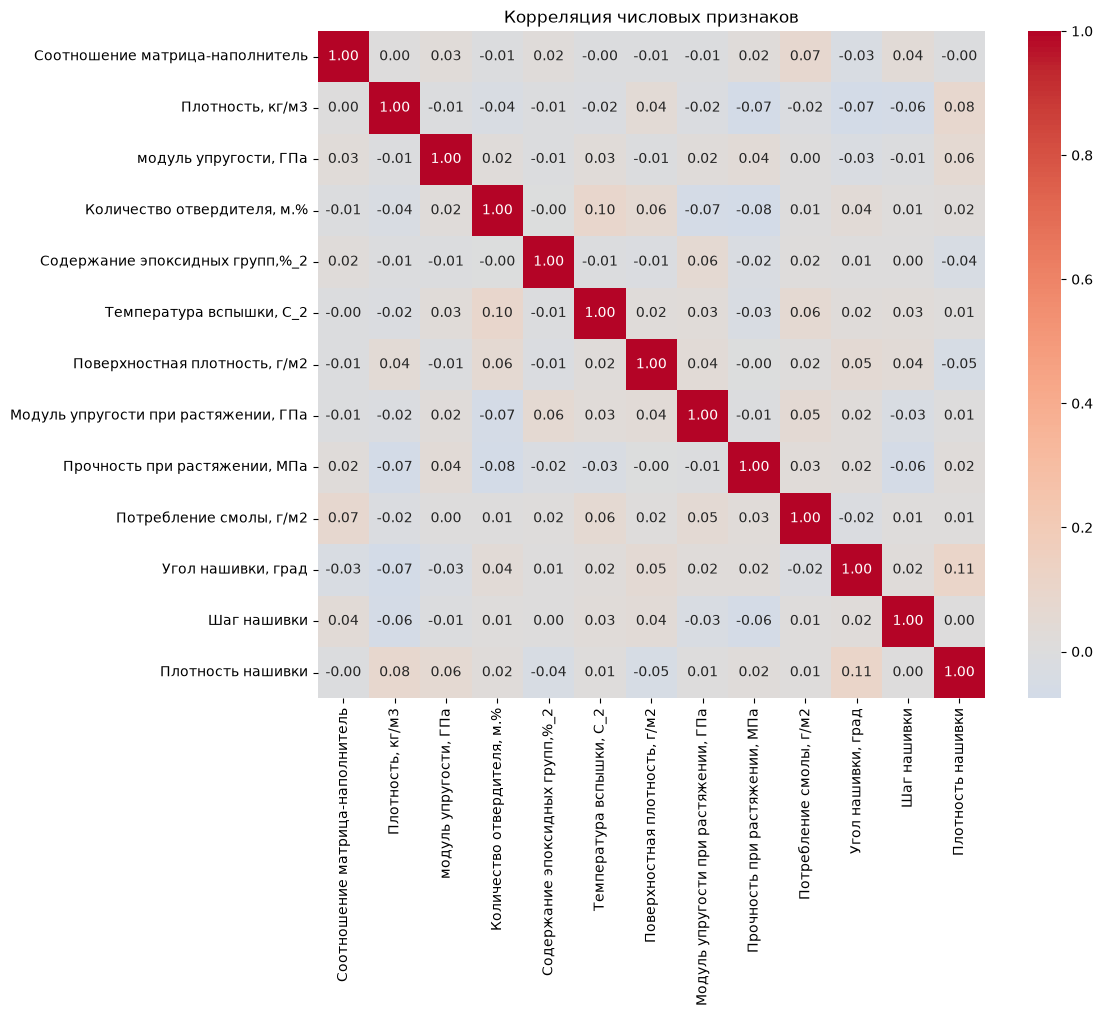

In [10]:
numeric_all = df.select_dtypes(include=[np.number])
if numeric_all.shape[1] > 1:
    plt.figure(figsize=(12, 10))
    sns.heatmap(numeric_all.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
    plt.title('Корреляция числовых признаков')
    plt.tight_layout()
    plt.show()

При анализе датасета не было выявленно особых выбросов, все значения в целом могут быть реальными. Карелации признаков тоже нету.